# Preprocessing Perturbations Preview

This notebook previews **all preprocessing perturbation variants** implemented in `Perturbation/pipeline_perturbations.py` so you can visually check how each one changes the images.

Variants covered:
- `downsample_nearest`
- `downsample_bilinear`
- `downsample_bicubic`
- `center_crop_pad`
- `grayscale_triplicate`


In [1]:
import sys
from pathlib import Path
import random

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torchvision.utils import make_grid


def find_repo_root(start: Path) -> Path:
    markers = ["main.py", "Datasets", "Metrics", "Models", "Perturbation"]
    for candidate in [start, *start.parents]:
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise RuntimeError("Could not locate repository root from current working directory.")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Resolved REPO_ROOT: {REPO_ROOT}")

from Datasets.unified_dataset_loader import make_default_loader
from Perturbation.pipeline_perturbations import _apply_preprocessing_variation



Resolved REPO_ROOT: c:\Users\sofia\OneDrive\Desktop\Project_Master_2\Group07_Improving_Metrics


In [2]:
# ---- Config ----
DATASET_NAME = "celeba"        # mnist | cifar10 | celeba | chestxray14
DATA_ROOT = str(REPO_ROOT / "data" / "CelebA")  # change only if your data is outside repo/data
IMAGE_SIZE = 128
NUM_SAMPLES = 8
RANDOM_SEED = 10

# scales used for all variants (grayscale also accepts scale, but visually it does not depend much on it)
SCALES = [0.5, 0.75]

VARIANTS = [
    "downsample_nearest",
    "downsample_bilinear",
    "downsample_bicubic",
    "center_crop_pad",
    "grayscale_triplicate",
]



In [3]:
# Reproducibility
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

loader = make_default_loader(
    dataset_name=DATASET_NAME,
    data_root=DATA_ROOT,
    image_size=IMAGE_SIZE,
)

try:
    ds = loader.get_dataset(train=False, download=False)
except Exception as exc:
    print(f"Local load failed ({exc}). Trying download=True ...")
    ds = loader.get_dataset(train=False, download=True)

dataloader = DataLoader(ds, batch_size=NUM_SAMPLES, shuffle=True, num_workers=0)
original_batch, _ = next(iter(dataloader))

print(f"Loaded batch: {tuple(original_batch.shape)} from dataset={DATASET_NAME}")


Loaded batch: (8, 3, 128, 128) from dataset=celeba


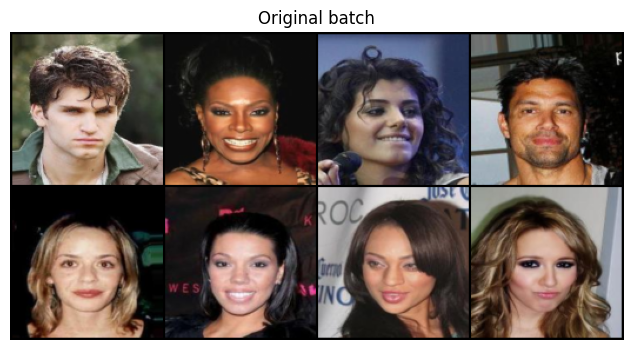

In [4]:
def to_display_batch(x: torch.Tensor) -> torch.Tensor:
    """Convert [-1,1] tensors to [0,1] for plotting."""
    return ((x.clamp(-1.0, 1.0) + 1.0) / 2.0).clamp(0.0, 1.0)

def show_grid(batch: torch.Tensor, title: str, nrow: int = 4):
    grid = make_grid(to_display_batch(batch), nrow=nrow)
    plt.figure(figsize=(12, 4))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.title(title)
    plt.axis("off")
    plt.show()

show_grid(original_batch, "Original batch")


In [5]:
# Apply every preprocessing variant at each scale and keep outputs
results = []

for variant in VARIANTS:
    for scale in SCALES:
        perturbed = _apply_preprocessing_variation(
            samples=original_batch,
            variant=variant,
            scale=scale,
        )
        mad = torch.mean(torch.abs(perturbed - original_batch)).item()
        results.append({
            "variant": variant,
            "scale": scale,
            "batch": perturbed,
            "mean_abs_diff": mad,
        })

print(f"Computed {len(results)} perturbed batches.")


Computed 10 perturbed batches.


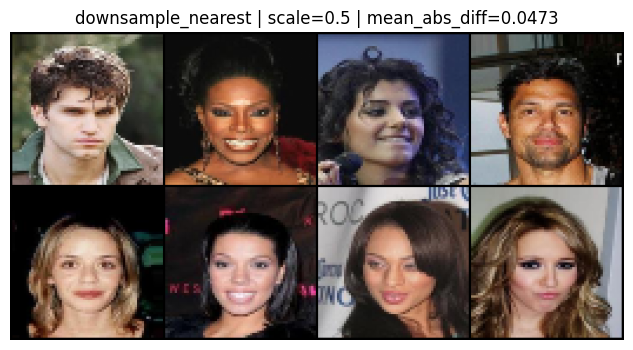

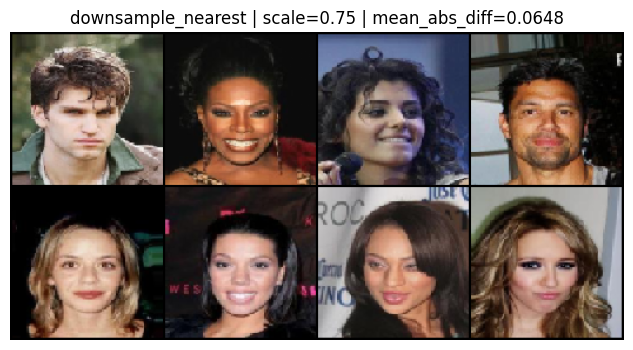

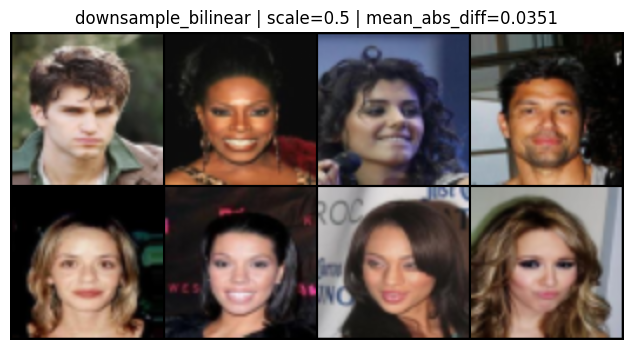

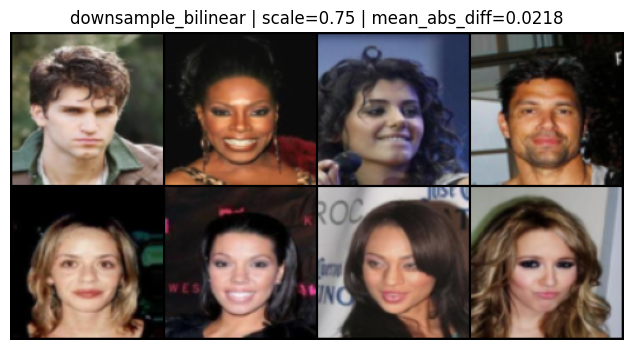

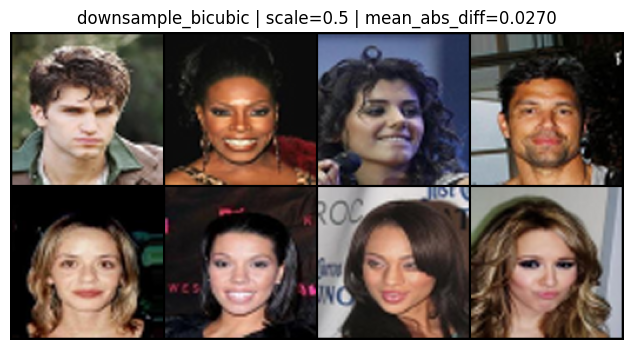

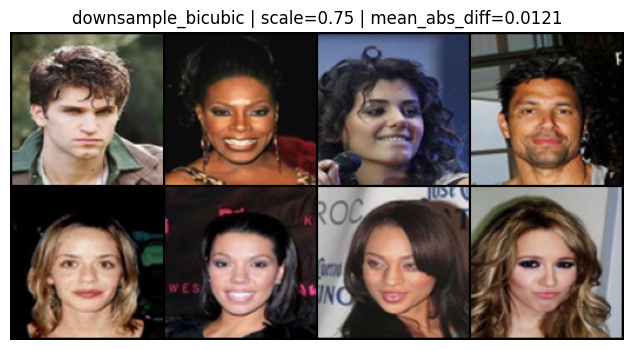

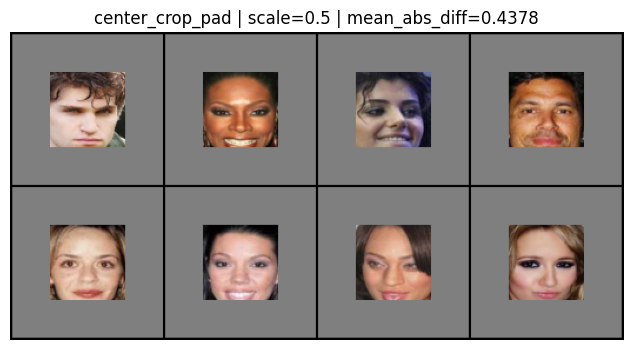

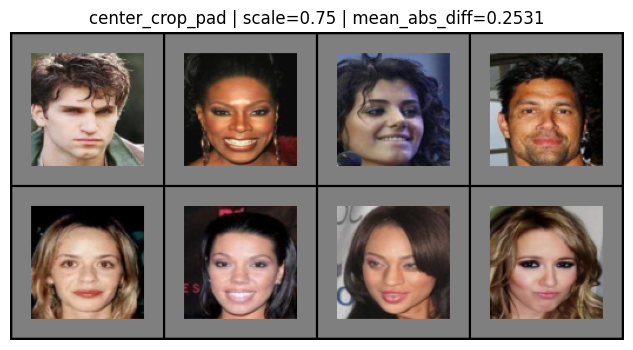

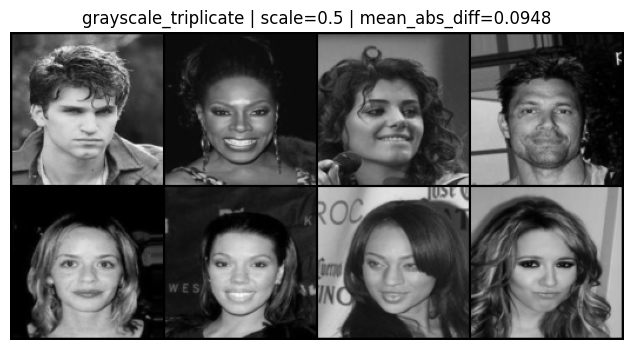

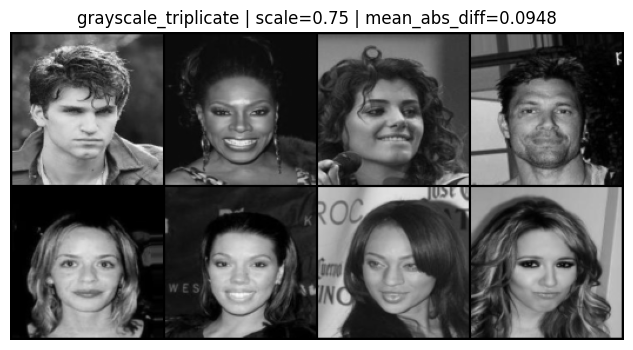

In [6]:
# Visualize all outputs (one grid per variant-scale pair)
for item in results:
    title = f"{item['variant']} | scale={item['scale']} | mean_abs_diff={item['mean_abs_diff']:.4f}"
    show_grid(item["batch"], title)


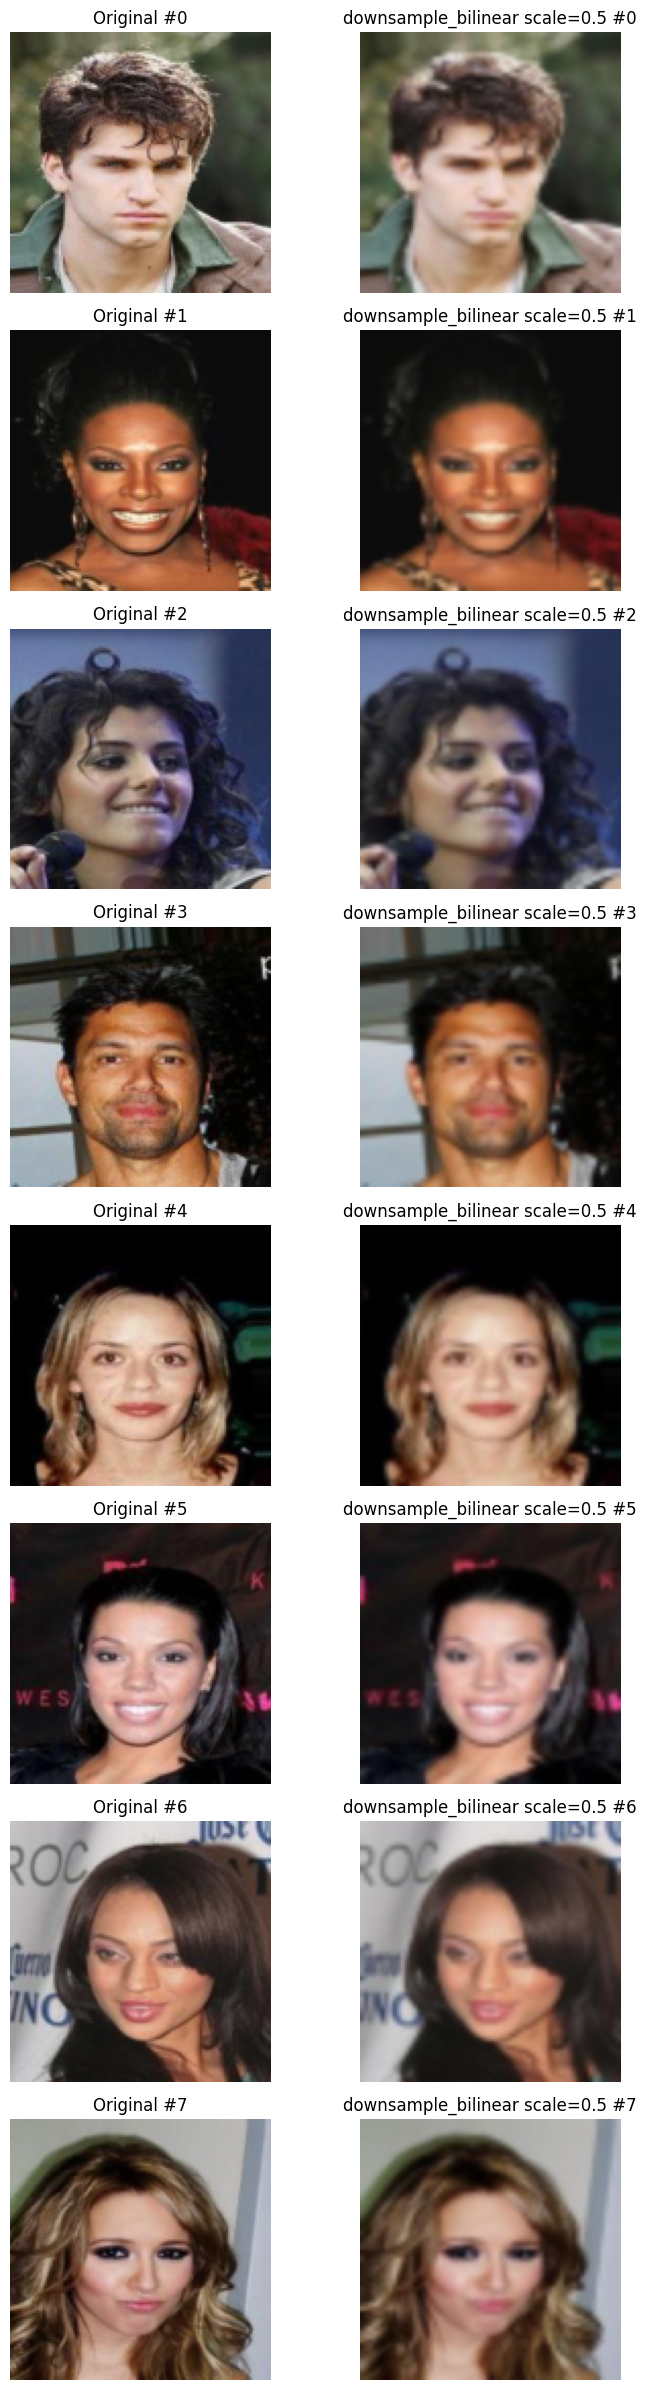

In [7]:
# Side-by-side comparison per sample for one selected setting
SELECTED_VARIANT = "downsample_bilinear"
SELECTED_SCALE = 0.5

picked = [r for r in results if r["variant"] == SELECTED_VARIANT and r["scale"] == SELECTED_SCALE][0]
perturbed = picked["batch"]

n = min(NUM_SAMPLES, original_batch.shape[0])
fig, axes = plt.subplots(n, 2, figsize=(8, 3 * n))
if n == 1:
    axes = [axes]

for i in range(n):
    o = to_display_batch(original_batch[i:i+1])[0].permute(1, 2, 0).cpu().numpy()
    p = to_display_batch(perturbed[i:i+1])[0].permute(1, 2, 0).cpu().numpy()

    axes[i][0].imshow(o)
    axes[i][0].set_title(f"Original #{i}")
    axes[i][0].axis("off")

    axes[i][1].imshow(p)
    axes[i][1].set_title(f"{SELECTED_VARIANT} scale={SELECTED_SCALE} #{i}")
    axes[i][1].axis("off")

plt.tight_layout()
plt.show()


In [8]:
# Optional: save one preview image per variant-scale to disk
OUT_DIR = Path("outputs/preprocessing_previews")
OUT_DIR.mkdir(parents=True, exist_ok=True)

for item in results:
    batch = item["batch"]
    variant = item["variant"]
    scale = str(item["scale"]).replace(".", "p")

    grid = make_grid(to_display_batch(batch), nrow=4)
    out_path = OUT_DIR / f"{DATASET_NAME}_{variant}_scale{scale}.png"

    plt.figure(figsize=(12, 4))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.title(f"{variant} scale={item['scale']}")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close()

print(f"Saved preview grids to: {OUT_DIR.resolve()}")


Saved preview grids to: C:\Users\sofia\OneDrive\Desktop\Project_Master_2\Group07_Improving_Metrics\Notebooks\outputs\preprocessing_previews
